# Lonfall DT testing
This notebook is similar to the landfall_DT_testing.ipynb notebook, but for the AR Days intersecting the -126 W, completely off the coast in our study. Mostly created for testing purposes, but fun to play around with. Most of the comments made in that notebook apply here as wel

In [1]:
import xarray as xa
import itertools
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cftime

In [2]:
def plot_landmask_and_wall(x, y):
    land = xa.open_dataset('/glade/derecho/scratch/tcorrie/regrids/landmask_regridded.nc')
    wall = land.sel(lon=-126, method='nearest').sel(lat=slice(32.5,48.51))
    fig, ax = plt.subplots(figsize=(x, y))
    land.LANDMASK.plot(ax=ax)
    ax.scatter([-126]*len(wall.lat), wall.lat, color='r', s=5)

In [3]:
def set_to_zero(ds):
    ds_nonnan = ds.fillna(0)
    ds_nonnanneg = ds_nonnan.clip(min=0)
    return ds_nonnanneg

In [4]:
wusd3 = pd.read_csv('../wusd3_gcms.csv', index_col=0)
wusd3 = wusd3.drop(index=6).reset_index(drop=True)
wusd3

,Model,Model Name,Member,Calendar
0,access-cm2,ACCESS-CM2,r5i1p1f1,standard
1,canesm5,CanESM5,r1i1p2f1,365_day
2,cesm2,CESM2,r11i1p1f1,365_day
3,cnrm-esm2-1,CNRM-ESM2-1,r1i1p1f2,standard
4,ec-earth3,EC-Earth3,r1i1p1f1,standard
5,ec-earth3-veg,EC-Earth3-Veg,r1i1p1f1,standard
6,fgoals-g3,FGOALS-g3,r1i1p1f1,365_day
7,giss-e2-1-g,GISS-E2-1-G,r1i1p1f2,365_day
8,miroc6,MIROC6,r1i1p1f1,standard
9,mpi-esm1-2-hr,MPI-ESM1-2-HR,r3i1p1f1,standard


In [5]:
def plot_lonfall(tidx, model, member, ardt):
    ARmask = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARmasks/{ardt}/ARmask.{model}.{member}.nc').isel(time=tidx)
    ARmask = set_to_zero(ARmask)
    land = xa.open_dataset('/glade/derecho/scratch/tcorrie/regrids/landmask_regridded.nc')
    wall = ARmask.sel(lon=-126, method='nearest').sel(lat=slice(32.5,48.51))
    ARwall = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARwall/{ardt}/ARwall.{ardt}.{model}.{member}.nc').isel(time=tidx)
    ARwall = set_to_zero(ARwall)
    ARlonfall = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARlonfall/{ardt}/ARlonfall.{ardt}.{model}.{member}.nc').isel(time=tidx)
    ARlonfall = set_to_zero(ARlonfall)

    def get_wall_coords(min_lat, max_lat):
        wall_subs = wall.sel(lat=slice(min_lat, max_lat))
        wall_lats = wall_subs.lat
        wall_lons = [-126]*len(wall_subs.lat)
        return(wall_lons, wall_lats)

    wall_lons_wus, wall_lats_wus = get_wall_coords(32.5,48.51)
    wall_lons_sca, wall_lats_sca = get_wall_coords(32.5,37.21)
    wall_lons_nca, wall_lats_nca = get_wall_coords(37.2,42.01)
    wall_lons_or, wall_lats_or = get_wall_coords(42.0,46.31)
    wall_lons_wa, wall_lats_wa = get_wall_coords(46.3,48.51)

    def get_lonfall_extent(ARwall, wall_lats):
        lonfall_extent_pixels = [(key, len(list(group))) for key, group in itertools.groupby(ARwall.ARwall.sel(lat=wall_lats).values) if key == 1]
        lonfall_extent_widths = [lep[1]/10 for lep in lonfall_extent_pixels]
        widths_list = ", ".join([f"{ln}\u00b0" for ln in lonfall_extent_widths])
        return widths_list

    land_widths_wus = get_lonfall_extent(ARwall, wall_lats_wus)
    land_widths_sca = get_lonfall_extent(ARwall, wall_lats_sca)
    land_widths_nca = get_lonfall_extent(ARwall, wall_lats_nca)
    land_widths_or = get_lonfall_extent(ARwall, wall_lats_or)
    land_widths_wa = get_lonfall_extent(ARwall, wall_lats_wa)

    is_lonfall_wus = str(bool(ARlonfall.lonfall_wus.values))
    is_lonfall_sca = str(bool(ARlonfall.lonfall_sca.values))
    is_lonfall_nca = str(bool(ARlonfall.lonfall_nca.values))
    is_lonfall_or = str(bool(ARlonfall.lonfall_or.values))
    is_lonfall_wa = str(bool(ARlonfall.lonfall_wa.values))

    fig, ax = plt.subplots(2, 2, figsize=(13,8))
    ax[1,0].scatter(ARwall.lat, ARwall.ARwall, color='r')
    ax[1,0].vlines([32.5, 37.2, 42, 46.3, 48.5], 0, 1, linestyle='dashed', colors='k')
    ax[1,0].text(35, 0.9, 'SCA', ha='center')
    ax[1,0].text(40, 0.9, 'NCA', ha='center')
    ax[1,0].text(44, 0.9, 'OR', ha='center')
    ax[1,0].text(47.5, 0.9, 'WA', ha='center')
    ax[1,0].text(50, 1.08, 'AR extent:'+land_widths_wus, ha='right')
    ax[1,0].text(30, 1.08, 'Lonfalling AR: '+is_lonfall_wus)
    
    ax[1,1].scatter(wall_lats_sca, ARwall.ARwall.sel(lat=slice(32.5,37.21)), color='cyan')
    ax[1,1].scatter(wall_lats_nca, ARwall.ARwall.sel(lat=slice(37.2,42.01)), color='blue')
    ax[1,1].scatter(wall_lats_or, ARwall.ARwall.sel(lat=slice(42.0,46.31)), color='green')
    ax[1,1].scatter(wall_lats_wa, ARwall.ARwall.sel(lat=slice(46.3,48.51)), color='red')
    ax[1,1].vlines([32.5, 37.2, 42, 46.3, 48.5], 0, 1, linestyle='dashed', colors='k')
    ax[1,1].text(35, 0.9, 'SCA', ha='center')
    ax[1,1].text(40, 0.9, 'NCA', ha='center')
    ax[1,1].text(44, 0.9, 'OR', ha='center')
    ax[1,1].text(47.5, 0.9, 'WA', ha='center')
    
    ARmask.ARmask.plot(ax=ax[0,0])
    
    ARmask.ARmask.plot(ax=ax[0,1])
    ax[0,0].scatter(wall_lons_wus, wall_lats_wus, color='r', s=5)
    
    ax[0,1].scatter(wall_lons_sca, wall_lats_sca, color='cyan', s=5)
    ax[0,1].scatter(wall_lons_nca, wall_lats_nca, color='blue', s=5)
    ax[0,1].scatter(wall_lons_or, wall_lats_or, color='green', s=5)
    ax[0,1].scatter(wall_lons_wa, wall_lats_wa, color='red', s=5)
    
    ax[1,1].text(35, 0.5, land_widths_sca, ha='center', color='cyan')
    ax[1,1].text(40, 0.5, land_widths_nca, ha='center', color='blue')
    ax[1,1].text(44, 0.5, land_widths_or, ha='center', color='green')
    ax[1,1].text(47.5, 0.5, land_widths_wa, ha='center', color='red')
    ax[1,1].text(35, 0.25, f"In region:\n{is_lonfall_sca}", ha='center', color='cyan')
    ax[1,1].text(40, 0.25, f"In region:\n{is_lonfall_nca}", ha='center', color='blue')
    ax[1,1].text(44, 0.25, f"In region:\n{is_lonfall_or}", ha='center', color='green')
    ax[1,1].text(47.5, 0.25, f"In region:\n{is_lonfall_wa}", ha='center', color='red')
    fig.suptitle(f"ARDT: {ardt}, model_config: {model}_{member}", size=20)

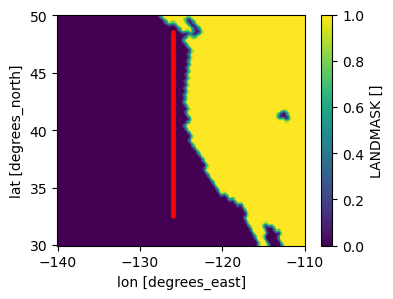

In [6]:
plot_landmask_and_wall(4, 3)

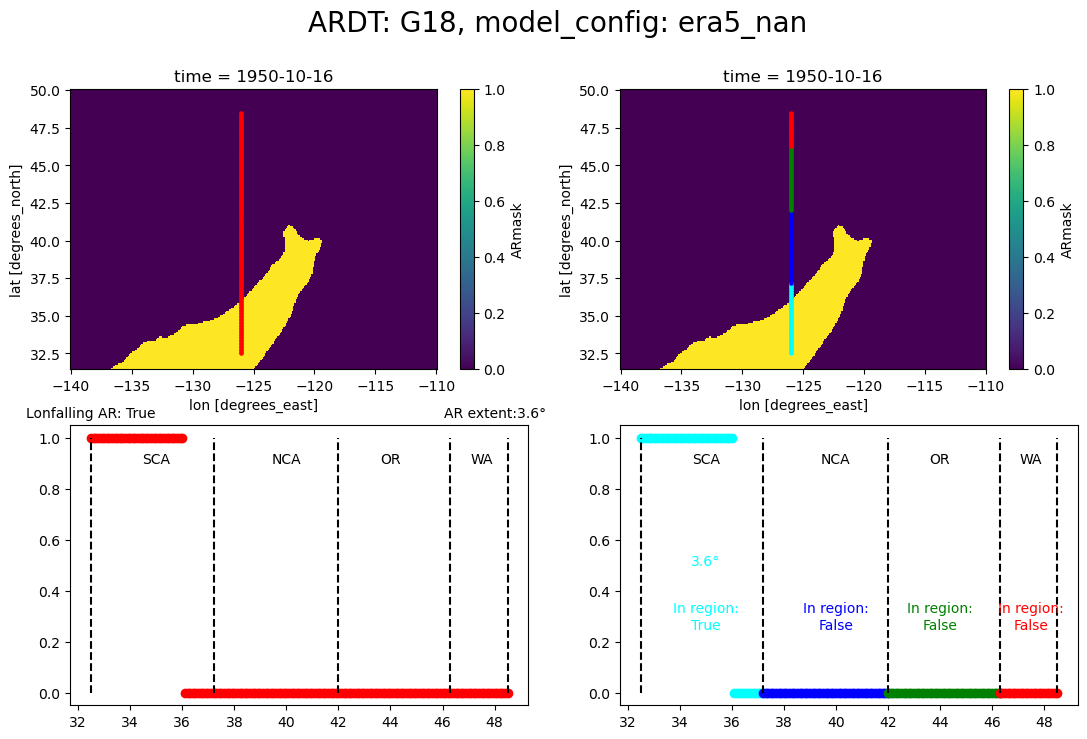

In [7]:
tidx = 45 #365*46+147
model = 'era5'
member = 'nan'
ardt = 'G18'
plot_lonfall(tidx, model, member, ardt)

In [8]:
ARwall_g18_era5 = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARwall/G18/ARwall.G18.era5.nan.nc', use_cftime=True)
ARwall_te_era5 = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARwall/TE/ARwall.TE.era5.nan.nc', use_cftime=True)
ARwall_tARget_era5 = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARwall/tARget/ARwall.tARget.era5.nan.nc', use_cftime=True)

ARlonfall_g18_era5 = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARlonfall/G18/ARlonfall.G18.era5.nan.nc', use_cftime=True)
ARlonfall_te_era5 = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARlonfall/TE/ARlonfall.TE.era5.nan.nc', use_cftime=True)
ARlonfall_tARget_era5 = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARlonfall/tARget/ARlonfall.tARget.era5.nan.nc', use_cftime=True)

ARwall_tARget_era5 = set_to_zero(ARwall_tARget_era5)
ARlonfall_tARget_era5 = set_to_zero(ARlonfall_tARget_era5)

ARwall_g18_cold_era5 = ARwall_g18_era5.where((ARwall_g18_era5.time.dt.month >= 10) | (ARwall_g18_era5.time.dt.month <= 3), drop=True)
ARwall_te_cold_era5 = ARwall_te_era5.where((ARwall_te_era5.time.dt.month >= 10) | (ARwall_te_era5.time.dt.month <= 3), drop=True)
ARwall_tARget_cold_era5 = ARwall_tARget_era5.where((ARwall_tARget_era5.time.dt.month >= 10) | (ARwall_tARget_era5.time.dt.month <= 3), drop=True)

ARlonfall_g18_cold_era5 = ARlonfall_g18_era5.where((ARlonfall_g18_era5.time.dt.month >= 10) | (ARlonfall_g18_era5.time.dt.month <= 3), drop=True)
ARlonfall_te_cold_era5 = ARlonfall_te_era5.where((ARlonfall_te_era5.time.dt.month >= 10) | (ARlonfall_te_era5.time.dt.month <= 3), drop=True)
ARlonfall_tARget_cold_era5 = ARlonfall_tARget_era5.where((ARlonfall_tARget_era5.time.dt.month >= 10) | (ARlonfall_tARget_era5.time.dt.month <= 3), drop=True)

ARlonfall_g18_cold_era5_times = ARlonfall_g18_cold_era5.where(ARlonfall_g18_cold_era5.lonfall_wus == 1, drop=True).time.values
ARlonfall_te_cold_era5_times = ARlonfall_te_cold_era5.where(ARlonfall_te_cold_era5.lonfall_wus == 1, drop=True).time.values
ARlonfall_tARget_cold_era5_times = ARlonfall_tARget_cold_era5.where(ARlonfall_tARget_cold_era5.lonfall_wus == 1, drop=True).time.values

ARlonfall_count_g18_era5 = ARwall_g18_cold_era5.ARwall.sel(time=ARlonfall_g18_cold_era5_times).sum(dim='time')
ARlonfall_count_te_era5 = ARwall_te_cold_era5.ARwall.sel(time=ARlonfall_te_cold_era5_times).sum(dim='time')
ARlonfall_count_tARget_era5 = ARwall_tARget_cold_era5.ARwall.sel(time=ARlonfall_tARget_cold_era5_times).sum(dim='time')

In [9]:
cmip6_ARlonfall = xa.Dataset(
    coords=dict(lat=('lat', ARlonfall_count_g18_era5.lat.values), idx=('idx', np.arange(15)), time_period=('time_period', ["historical", "near-term", "end-of-century"]), ardt=('ardt', ['G18', 'TE', 'tARget'])),
    data_vars = dict(ARcounts=(['lat', 'idx', 'time_period', 'ardt'], np.zeros((len(ARlonfall_count_g18_era5.lat.values), 15, 3, 3))))
)

for i in wusd3.index:
    model = wusd3.loc[i, 'Model']
    member = wusd3.loc[i, 'Member']
    calendar = wusd3.loc[i, 'Calendar']

    ARwall_g18 = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARwall/G18/ARwall.G18.{model}.{member}.nc', use_cftime=True)
    ARwall_te = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARwall/TE/ARwall.TE.{model}.{member}.nc', use_cftime=True)
    ARwall_tARget = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARwall/tARget/ARwall.tARget.{model}.{member}.nc', use_cftime=True)
    
    ARlonfall_g18 = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARlonfall/G18/ARlonfall.G18.{model}.{member}.nc', use_cftime=True)
    ARlonfall_te = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARlonfall/TE/ARlonfall.TE.{model}.{member}.nc', use_cftime=True)
    ARlonfall_tARget = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARlonfall/tARget/ARlonfall.tARget.{model}.{member}.nc', use_cftime=True)
    
    ARwall_tARget = set_to_zero(ARwall_tARget)
    ARlonfall_tARget = set_to_zero(ARlonfall_tARget)

    for tp in ['historical', 'near-term', 'end-of-century']:
        print(f'{model}/{member}/{tp}')
        syear = 1980 if tp=='historical' else 2016 if tp=='near-term' else 2066 if tp=='end-of-century' else -9999
        eyear = 2014 if tp=='historical' else 2050 if tp=='near-term' else 2100 if tp=='end-of-century' else -9999
        sdate = cftime.datetime(syear, 9, 1, calendar=calendar)
        edate = cftime.datetime(eyear, 8, 31, calendar=calendar) if i < 14 else cftime.datetime(eyear, 8, 30, calendar=calendar)
        
        ARwall_g18_sliced = ARwall_g18.sel(time=slice(sdate,edate))
        ARwall_te_sliced = ARwall_te.sel(time=slice(sdate,edate))
        ARwall_tARget_sliced = ARwall_tARget.sel(time=slice(sdate,edate))
        
        ARlonfall_g18_sliced = ARlonfall_g18.sel(time=slice(sdate,edate))
        ARlonfall_te_sliced = ARlonfall_te.sel(time=slice(sdate,edate))
        ARlonfall_tARget_sliced = ARlonfall_tARget.sel(time=slice(sdate,edate))
    
        ARwall_g18_cold = ARwall_g18_sliced.where((ARwall_g18_sliced.time.dt.month >= 10) | (ARwall_g18_sliced.time.dt.month <= 3), drop=True)
        ARwall_te_cold = ARwall_te_sliced.where((ARwall_te_sliced.time.dt.month >= 10) | (ARwall_te_sliced.time.dt.month <= 3), drop=True)
        ARwall_tARget_cold = ARwall_tARget_sliced.where((ARwall_tARget_sliced.time.dt.month >= 10) | (ARwall_tARget_sliced.time.dt.month <= 3), drop=True)
        
        ARlonfall_g18_cold = ARlonfall_g18_sliced.where((ARlonfall_g18_sliced.time.dt.month >= 10) | (ARlonfall_g18_sliced.time.dt.month <= 3), drop=True)
        ARlonfall_te_cold = ARlonfall_te_sliced.where((ARlonfall_te_sliced.time.dt.month >= 10) | (ARlonfall_te_sliced.time.dt.month <= 3), drop=True)
        ARlonfall_tARget_cold = ARlonfall_tARget_sliced.where((ARlonfall_tARget_sliced.time.dt.month >= 10) | (ARlonfall_tARget_sliced.time.dt.month <= 3), drop=True)
        
        ARlonfall_g18_cold_times = ARlonfall_g18_cold.where(ARlonfall_g18_cold.lonfall_wus == 1, drop=True).time.values
        ARlonfall_te_cold_times = ARlonfall_te_cold.where(ARlonfall_te_cold.lonfall_wus == 1, drop=True).time.values
        ARlonfall_tARget_cold_times = ARlonfall_tARget_cold.where(ARlonfall_tARget_cold.lonfall_wus == 1, drop=True).time.values
        
        ARlonfall_count_g18 = ARwall_g18_cold.ARwall.sel(time=ARlonfall_g18_cold_times).sum(dim='time')
        ARlonfall_count_te = ARwall_te_cold.ARwall.sel(time=ARlonfall_te_cold_times).sum(dim='time')
        ARlonfall_count_tARget = ARwall_tARget_cold.ARwall.sel(time=ARlonfall_tARget_cold_times).sum(dim='time')

        cmip6_ARlonfall.loc[{'idx': i, 'time_period': tp, 'ardt': 'G18'}] = (ARlonfall_count_g18/34)
        cmip6_ARlonfall.loc[{'idx': i, 'time_period': tp, 'ardt': 'TE'}] = (ARlonfall_count_te/34)
        cmip6_ARlonfall.loc[{'idx': i, 'time_period': tp, 'ardt': 'tARget'}] = (ARlonfall_count_tARget/34)

access-cm2/r5i1p1f1/historical
access-cm2/r5i1p1f1/near-term
access-cm2/r5i1p1f1/end-of-century
canesm5/r1i1p2f1/historical
canesm5/r1i1p2f1/near-term
canesm5/r1i1p2f1/end-of-century
cesm2/r11i1p1f1/historical
cesm2/r11i1p1f1/near-term
cesm2/r11i1p1f1/end-of-century
cnrm-esm2-1/r1i1p1f2/historical
cnrm-esm2-1/r1i1p1f2/near-term
cnrm-esm2-1/r1i1p1f2/end-of-century
ec-earth3/r1i1p1f1/historical
ec-earth3/r1i1p1f1/near-term
ec-earth3/r1i1p1f1/end-of-century
ec-earth3-veg/r1i1p1f1/historical
ec-earth3-veg/r1i1p1f1/near-term
ec-earth3-veg/r1i1p1f1/end-of-century
fgoals-g3/r1i1p1f1/historical
fgoals-g3/r1i1p1f1/near-term
fgoals-g3/r1i1p1f1/end-of-century
giss-e2-1-g/r1i1p1f2/historical
giss-e2-1-g/r1i1p1f2/near-term
giss-e2-1-g/r1i1p1f2/end-of-century
miroc6/r1i1p1f1/historical
miroc6/r1i1p1f1/near-term
miroc6/r1i1p1f1/end-of-century
mpi-esm1-2-hr/r3i1p1f1/historical
mpi-esm1-2-hr/r3i1p1f1/near-term
mpi-esm1-2-hr/r3i1p1f1/end-of-century
mpi-esm1-2-hr/r7i1p1f1/historical
mpi-esm1-2-hr/r7i1p1f

In [10]:
cesm2le_ARlonfall = xa.Dataset(
    coords=dict(lat=('lat', ARlonfall_count_g18_era5.lat.values), idx=('idx', np.arange(10)), time_period=('time_period', ["historical", "near-term", "end-of-century"]), ardt=('ardt', ['G18', 'TE', 'tARget'])),
    data_vars = dict(ARcounts=(['lat', 'idx', 'time_period', 'ardt'], np.zeros((len(ARlonfall_count_g18_era5.lat.values), 10, 3, 3))))
)

for i in range(10):
    model = 'cesm2-le'
    member = str(1011+i*20)
    calendar = '365_day'

    ARwall_g18 = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARwall/G18/ARwall.G18.{model}.{member}.nc', use_cftime=True)
    ARwall_te = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARwall/TE/ARwall.TE.{model}.{member}.nc', use_cftime=True)
    ARwall_tARget = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARwall/tARget/ARwall.tARget.{model}.{member}.nc', use_cftime=True)
    
    ARlonfall_g18 = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARlonfall/G18/ARlonfall.G18.{model}.{member}.nc', use_cftime=True)
    ARlonfall_te = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARlonfall/TE/ARlonfall.TE.{model}.{member}.nc', use_cftime=True)
    ARlonfall_tARget = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARlonfall/tARget/ARlonfall.tARget.{model}.{member}.nc', use_cftime=True)
    
    ARwall_tARget = set_to_zero(ARwall_tARget)
    ARlonfall_tARget = set_to_zero(ARlonfall_tARget)

    for tp in ['historical', 'near-term', 'end-of-century']:
        print(f'{model}/{member}/{tp}')
        syear = 1980 if tp=='historical' else 2016 if tp=='near-term' else 2066 if tp=='end-of-century' else -9999
        eyear = 2014 if tp=='historical' else 2050 if tp=='near-term' else 2100 if tp=='end-of-century' else -9999
        sdate = cftime.datetime(syear, 9, 1, calendar=calendar)
        edate = cftime.datetime(eyear, 8, 31, calendar=calendar)
        
        ARwall_g18_sliced = ARwall_g18.sel(time=slice(sdate,edate))
        ARwall_te_sliced = ARwall_te.sel(time=slice(sdate,edate))
        ARwall_tARget_sliced = ARwall_tARget.sel(time=slice(sdate,edate))
        
        ARlonfall_g18_sliced = ARlonfall_g18.sel(time=slice(sdate,edate))
        ARlonfall_te_sliced = ARlonfall_te.sel(time=slice(sdate,edate))
        ARlonfall_tARget_sliced = ARlonfall_tARget.sel(time=slice(sdate,edate))
    
        ARwall_g18_cold = ARwall_g18_sliced.where((ARwall_g18_sliced.time.dt.month >= 10) | (ARwall_g18_sliced.time.dt.month <= 3), drop=True)
        ARwall_te_cold = ARwall_te_sliced.where((ARwall_te_sliced.time.dt.month >= 10) | (ARwall_te_sliced.time.dt.month <= 3), drop=True)
        ARwall_tARget_cold = ARwall_tARget_sliced.where((ARwall_tARget_sliced.time.dt.month >= 10) | (ARwall_tARget_sliced.time.dt.month <= 3), drop=True)
        
        ARlonfall_g18_cold = ARlonfall_g18_sliced.where((ARlonfall_g18_sliced.time.dt.month >= 10) | (ARlonfall_g18_sliced.time.dt.month <= 3), drop=True)
        ARlonfall_te_cold = ARlonfall_te_sliced.where((ARlonfall_te_sliced.time.dt.month >= 10) | (ARlonfall_te_sliced.time.dt.month <= 3), drop=True)
        ARlonfall_tARget_cold = ARlonfall_tARget_sliced.where((ARlonfall_tARget_sliced.time.dt.month >= 10) | (ARlonfall_tARget_sliced.time.dt.month <= 3), drop=True)
        
        ARlonfall_g18_cold_times = ARlonfall_g18_cold.where(ARlonfall_g18_cold.lonfall_wus == 1, drop=True).time.values
        ARlonfall_te_cold_times = ARlonfall_te_cold.where(ARlonfall_te_cold.lonfall_wus == 1, drop=True).time.values
        ARlonfall_tARget_cold_times = ARlonfall_tARget_cold.where(ARlonfall_tARget_cold.lonfall_wus == 1, drop=True).time.values
        
        ARlonfall_count_g18 = ARwall_g18_cold.ARwall.sel(time=ARlonfall_g18_cold_times).sum(dim='time')
        ARlonfall_count_te = ARwall_te_cold.ARwall.sel(time=ARlonfall_te_cold_times).sum(dim='time')
        ARlonfall_count_tARget = ARwall_tARget_cold.ARwall.sel(time=ARlonfall_tARget_cold_times).sum(dim='time')

        cesm2le_ARlonfall.loc[{'idx': i, 'time_period': tp, 'ardt': 'G18'}] = (ARlonfall_count_g18/34)
        cesm2le_ARlonfall.loc[{'idx': i, 'time_period': tp, 'ardt': 'TE'}] = (ARlonfall_count_te/34)
        cesm2le_ARlonfall.loc[{'idx': i, 'time_period': tp, 'ardt': 'tARget'}] = (ARlonfall_count_tARget/34)

cesm2-le/1011/historical
cesm2-le/1011/near-term
cesm2-le/1011/end-of-century
cesm2-le/1031/historical
cesm2-le/1031/near-term
cesm2-le/1031/end-of-century
cesm2-le/1051/historical
cesm2-le/1051/near-term
cesm2-le/1051/end-of-century
cesm2-le/1071/historical
cesm2-le/1071/near-term
cesm2-le/1071/end-of-century
cesm2-le/1091/historical
cesm2-le/1091/near-term
cesm2-le/1091/end-of-century
cesm2-le/1111/historical
cesm2-le/1111/near-term
cesm2-le/1111/end-of-century
cesm2-le/1131/historical
cesm2-le/1131/near-term
cesm2-le/1131/end-of-century
cesm2-le/1151/historical
cesm2-le/1151/near-term
cesm2-le/1151/end-of-century
cesm2-le/1171/historical
cesm2-le/1171/near-term
cesm2-le/1171/end-of-century
cesm2-le/1191/historical
cesm2-le/1191/near-term
cesm2-le/1191/end-of-century


Text(0, 0.5, 'Latitude (°N)')

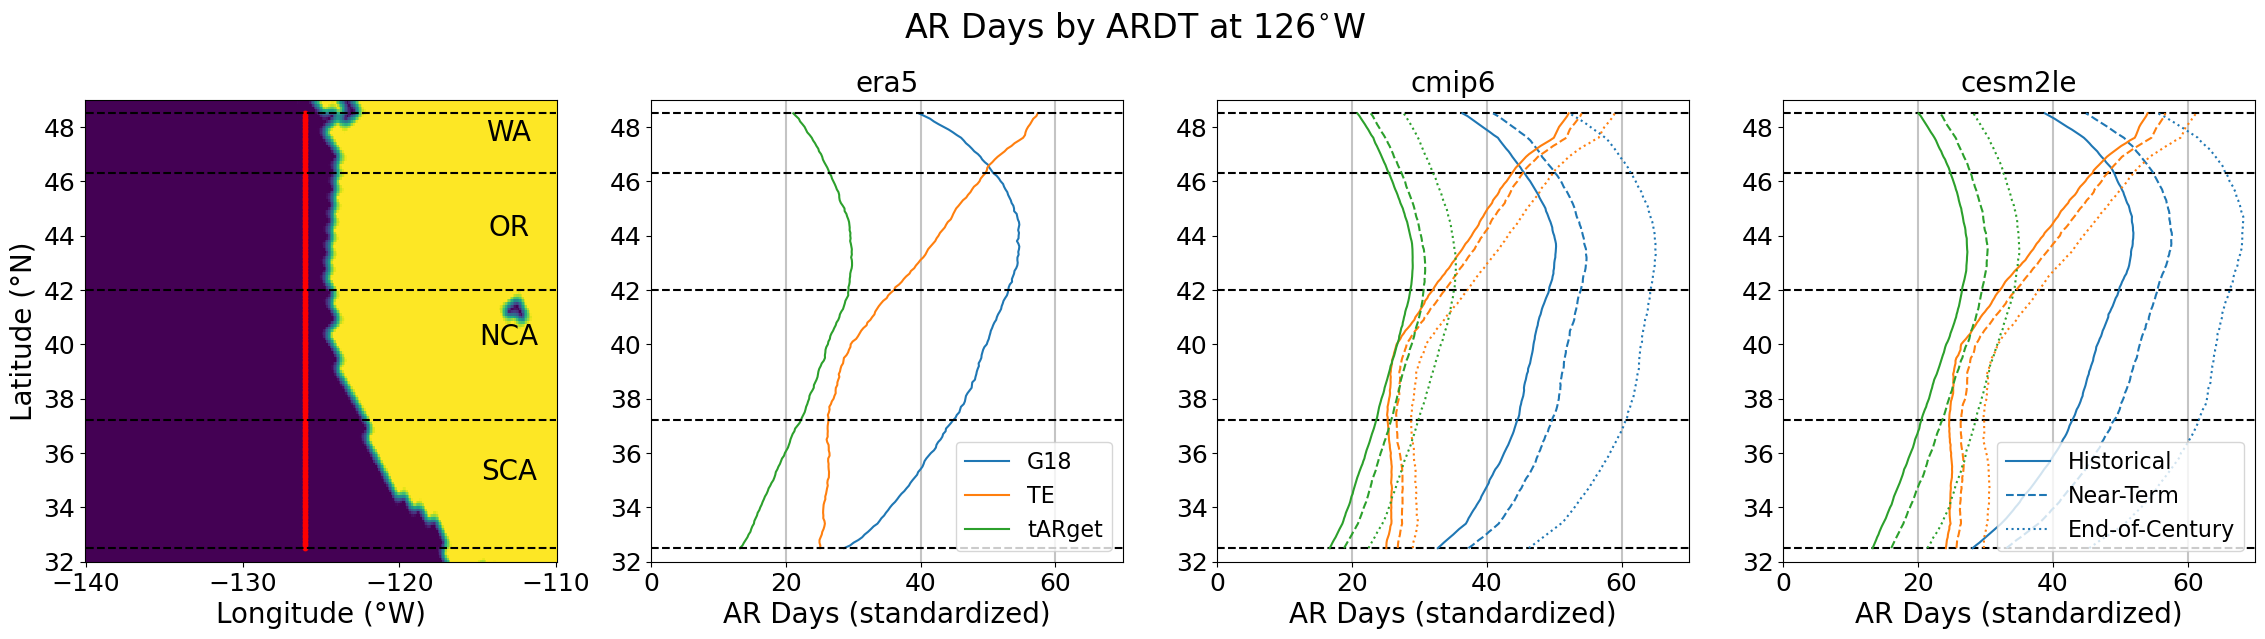

In [13]:
f3, a3 = plt.subplots(1, 4, figsize=(28,6))
a3[1].plot(ARlonfall_count_g18_era5/75, ARlonfall_count_g18_era5.lat, label='G18')
a3[1].plot(ARlonfall_count_te_era5/75, ARlonfall_count_te_era5.lat, label='TE')
a3[1].plot(ARlonfall_count_tARget_era5/75, ARlonfall_count_tARget_era5.lat, label='tARget')
f3.suptitle(r'AR Days by ARDT at 126$^{\circ}$W', fontsize=24, y=1.03)
a3[1].set_title('era5', fontsize=20)

cmip6_means = cmip6_ARlonfall.ARcounts.mean(dim=['idx'])
cmip6_stds = cmip6_ARlonfall.ARcounts.std(dim=['idx'])

cesm2le_means = cesm2le_ARlonfall.ARcounts.mean(dim=['idx'])

for i in range(4):
    a3[i].tick_params(axis='both', labelsize=18)

for i in range(1,4):
    a3[i].set_xlim(0,70)
    a3[i].grid(axis='x', which='major', linewidth=1.5, alpha=0.75)
    a3[i].hlines([32.5, 37.2, 42, 46.3, 48.5], 0, 70, linestyle='dashed', colors='k')

    a3[i].set_xlabel('AR Days (standardized)', fontsize=20)
a3[1].legend(loc='lower right', fontsize=16)

a3[0].text(-113, 35, 'SCA', ha='center', fontsize=20)
a3[0].text(-113, 40, 'NCA', ha='center', fontsize=20)
a3[0].text(-113, 44, 'OR', ha='center', fontsize=20)
a3[0].text(-113, 47.5, 'WA', ha='center', fontsize=20)



a3[2].plot(cmip6_means.sel(time_period='historical', ardt='G18'), cmip6_ARlonfall.lat, color='C0', linestyle='solid', label='Historical')
a3[2].plot(cmip6_means.sel(time_period='near-term', ardt='G18'), cmip6_ARlonfall.lat, color='C0', linestyle='dashed', label='Near-Term')
a3[2].plot(cmip6_means.sel(time_period='end-of-century', ardt='G18'), cmip6_ARlonfall.lat, color='C0', linestyle='dotted', label='End-of-Century')


a3[2].plot(cmip6_means.sel(time_period='historical', ardt='TE'), cmip6_ARlonfall.lat, color='C1', linestyle='solid')
a3[2].plot(cmip6_means.sel(time_period='near-term', ardt='TE'), cmip6_ARlonfall.lat, color='C1', linestyle='dashed')
a3[2].plot(cmip6_means.sel(time_period='end-of-century', ardt='TE'), cmip6_ARlonfall.lat, color='C1', linestyle='dotted')

a3[2].plot(cmip6_means.sel(time_period='historical', ardt='tARget'), cmip6_ARlonfall.lat, color='C2', linestyle='solid')
a3[2].plot(cmip6_means.sel(time_period='near-term', ardt='tARget'), cmip6_ARlonfall.lat, color='C2', linestyle='dashed')
a3[2].plot(cmip6_means.sel(time_period='end-of-century', ardt='tARget'), cmip6_ARlonfall.lat, color='C2', linestyle='dotted')


a3[3].plot(cesm2le_means.sel(time_period='historical', ardt='G18'), cesm2le_ARlonfall.lat, color='C0', linestyle='solid', label='Historical')
a3[3].plot(cesm2le_means.sel(time_period='near-term', ardt='G18'), cesm2le_ARlonfall.lat, color='C0', linestyle='dashed', label='Near-Term')
a3[3].plot(cesm2le_means.sel(time_period='end-of-century', ardt='G18'), cesm2le_ARlonfall.lat, color='C0', linestyle='dotted', label='End-of-Century')

a3[3].plot(cesm2le_means.sel(time_period='historical', ardt='TE'), cesm2le_ARlonfall.lat, color='C1', linestyle='solid')
a3[3].plot(cesm2le_means.sel(time_period='near-term', ardt='TE'), cesm2le_ARlonfall.lat, color='C1', linestyle='dashed')
a3[3].plot(cesm2le_means.sel(time_period='end-of-century', ardt='TE'), cesm2le_ARlonfall.lat, color='C1', linestyle='dotted')

a3[3].plot(cesm2le_means.sel(time_period='historical', ardt='tARget'), cesm2le_ARlonfall.lat, color='C2', linestyle='solid')
a3[3].plot(cesm2le_means.sel(time_period='near-term', ardt='tARget'), cesm2le_ARlonfall.lat, color='C2', linestyle='dashed')
a3[3].plot(cesm2le_means.sel(time_period='end-of-century', ardt='tARget'), cesm2le_ARlonfall.lat, color='C2', linestyle='dotted')
a3[3].legend(loc='lower right', fontsize=16)

a3[2].set_title('cmip6', fontsize=20)
a3[3].set_title('cesm2le', fontsize=20)

land = xa.open_dataset('/glade/derecho/scratch/tcorrie/regrids/landmask_regridded.nc')
wall = land.sel(lon=-126, method='nearest').sel(lat=slice(32.5,48.51))

land.LANDMASK.plot(ax=a3[0], add_colorbar=False)
a3[0].scatter([-126]*len(wall.lat), wall.lat, color='r', s=10)
for i in range(4):
    a3[i].set_ylim(32.0, 49)
a3[0].hlines([48.5, 46.3, 42, 37.2, 32.5], -140, -110, 'k', 'dashed')
a3[0].set_xlabel("Longitude (°W)", fontsize=20)
a3[0].set_ylabel("Latitude (°N)", fontsize=20)

In [14]:
f3.savefig('/glade/work/tcorrie/ARdata/Figures/coldseason_arcounts_at126W.png', bbox_inches='tight', dpi=1200)
f3.savefig('/glade/work/tcorrie/ARdata/Figures/JoC/coldseason_arcounts_at126W_supp.png', bbox_inches='tight', dpi=1200)